# PyMC-19 : Systemes Experts et Decisions Robustes

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jsboige/CoursIA/blob/main/MyIA.AI.Notebooks/Probas/_python_port/PyMC-19-Decision-Expert-Systems.ipynb)

## Objectifs d'apprentissage

A la fin de ce notebook, vous saurez :
- Construire un **systeme expert bayesien** de diagnostic
- Appliquer le critere **Minimax** pour des decisions robustes
- Implementer le **Minimax Regret** (Savage, 1951)
- Utiliser le critere **Hurwicz** pour ajuster le niveau d'optimisme
- Realiser une **analyse de sensibilite** pour tester la robustesse

**Prerequis** : PyMC-17 (reseaux de decision), PyMC-18 (valeur de l'information)

**Duree estimee** : 50 minutes

---

| Notebook precedent | Notebook suivant |
|--------------------|------------------|
| [PyMC-18 - Valeur de l'information](PyMC-18-Decision-Value-Information.ipynb) | [PyMC-20 - Decisions sequentielles](PyMC-20-Decision-Sequential.ipynb) |

## 1. Systemes Experts : Architecture

Un **systeme expert** simule le raisonnement d'un expert humain :
- **Base de connaissances** : regles, CPTs, priors
- **Moteur d'inference** : chainage avant, Bayes
- **Interface explicative** : justification des conclusions

### Jalons historiques

| Systeme | Annee | Domaine | Innovation cle |
|---------|-------|---------|----------------|
| DENDRAL | 1965 | Chimie | Premier systeme expert |
| MYCIN | 1976 | Medical | Facteurs de certitude, 600 regles |
| PROSPECTOR | 1979 | Geologie | Premiers reseaux bayesiens |
| R1/XCON | 1982 | Config VAX | Premier succes commercial |

Les systemes experts classiques souffraient de **fragilite** et de **mauvaise gestion de l'incertitude**.
L'approche bayesienne (Pearl, 1988) a resolu ces problemes.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import product
import warnings

warnings.filterwarnings("ignore")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 12
print("Imports OK")

Imports OK


## 2. Mini-systeme expert de diagnostic

On construit un systeme expert bayesien pour le diagnostic medical.
4 maladies, 4 symptomes, avec vraisemblances P(symptome|maladie).

In [2]:
class MiniExpertSystem:
    """Systeme expert bayesien de diagnostic."""
    
    def __init__(self):
        self.maladies = ["Grippe", "Rhume", "Covid", "Allergie"]
        self.symptomes = ["fievre", "toux", "fatigue", "eternuements"]
        
        # Priors
        self.priors = np.array([0.30, 0.50, 0.15, 0.05])
        
        # Vraisemblances P(symptome|maladie)
        self.likelihoods = np.array([
            # fievre, toux, fatigue, eternuements
            [0.90, 0.80, 0.90, 0.30],  # Grippe
            [0.30, 0.60, 0.40, 0.90],  # Rhume
            [0.85, 0.75, 0.80, 0.20],  # Covid
            [0.05, 0.30, 0.20, 0.95],  # Allergie
        ])
    
    def diagnose(self, observed):
        """Calcule les posteriors P(maladie|symptomes observes)."""
        observed_idx = [self.symptomes.index(s) for s in observed]
        absent_idx = [i for i in range(len(self.symptomes)) if i not in observed_idx]
        
        # P(symptomes|maladie) = produit des P(s_i|maladie)
        likelihood = np.ones(len(self.maladies))
        for i in observed_idx:
            likelihood *= self.likelihoods[:, i]
        for i in absent_idx:
            likelihood *= (1 - self.likelihoods[:, i])
        
        # Bayes
        unnormalized = self.priors * likelihood
        posteriors = unnormalized / unnormalized.sum()
        return posteriors


expert = MiniExpertSystem()
symptomes_obs = ["fievre", "toux", "fatigue"]
posteriors = expert.diagnose(symptomes_obs)

print(f"Symptomes observes : {', '.join(symptomes_obs)}\n")
print("Diagnostic (posterieurs) :")
order = np.argsort(-posteriors)
for i in order:
    bar = '#' * int(posteriors[i] * 40)
    print(f"  {expert.maladies[i]:10s} : {posteriors[i]:6.1%} {bar}")

Symptomes observes : fievre, toux, fatigue

Diagnostic (posterieurs) :
  Grippe     :  67.7% ###########################
  Covid      :  30.5% ############
  Rhume      :   1.8% 
  Allergie   :   0.0% 


### Interpretation

La **Grippe** est la plus probable car les 3 symptomes (fievre, toux, fatigue) correspondent
bien au profil (90%, 80%, 90%). L'**absence d'eternuements** penalise le Rhume (90% -> non observe)
et l'Allergie (95% -> non observe).

## 3. Critere Minimax

Quand les probabilites sont inconnues ou peu fiables, on utilise des criteres robustes.

$$a^* = \arg\max_a \min_s U(a, s)$$

On choisit l'action qui **maximise l'utilite dans le pire cas**.

In [3]:
def minimax_decision(actions, states, U):
    """Retourne (meilleure action, valeur du pire cas)."""
    worst_per_action = U.min(axis=1)  # min sur les etats pour chaque action
    best_idx = np.argmax(worst_per_action)
    return actions[best_idx], worst_per_action[best_idx]


# Scenario d'investissement
actions_inv = ["Obligations", "Actions", "Immobilier", "Cash"]
states_inv = ["Recession", "Stable", "Croissance"]
U_inv = np.array([
    [30000, 40000, 50000],   # Obligations
    [-20000, 50000, 120000], # Actions
    [-10000, 30000, 80000],  # Immobilier
    [20000, 20000, 20000]    # Cash
])

# Afficher la table
print("Analyse Minimax :\n")
header = f"{'Action':15s} | " + " | ".join(f"{s:>10s}" for s in states_inv) + " | Min"
print(header)
print("-" * len(header))

for a, action in enumerate(actions_inv):
    worst = U_inv[a].min()
    vals = " | ".join(f"{U_inv[a, s]:10.0f}" for s in range(len(states_inv)))
    print(f"{action:15s} | {vals} | {worst:8.0f}")

best_mm, val_mm = minimax_decision(actions_inv, states_inv, U_inv)
print(f"\n=> Minimax : {best_mm} (pire cas = {val_mm:.0f})")

Analyse Minimax :

Action          |  Recession |     Stable | Croissance | Min
------------------------------------------------------------
Obligations     |      30000 |      40000 |      50000 |    30000
Actions         |     -20000 |      50000 |     120000 |   -20000
Immobilier      |     -10000 |      30000 |      80000 |   -10000
Cash            |      20000 |      20000 |      20000 |    20000

=> Minimax : Obligations (pire cas = 30000)


### Quand utiliser Minimax ?

| Situation | Pourquoi |
|-----------|----------|
| Erreurs catastrophiques | Pire cas inacceptable |
| Adversaire reel | L'autre optimise contre vous |
| Incertitude totale | Aucune probabilite fiable |
| Decision irreversible | Pas de seconde chance |

## 4. Critere Minimax Regret (Savage, 1951)

Le **regret** mesure l'ecart avec ce qu'on aurait pu faire de mieux :

$$\text{Regret}(a, s) = \max_{a'} U(a', s) - U(a, s)$$

$$a^* = \arg\min_a \max_s \text{Regret}(a, s)$$

In [4]:
def minimax_regret_decision(actions, states, U):
    """Retourne (meilleure action, max_regret, matrice_regret)."""
    best_per_state = U.max(axis=0)  # meilleure action pour chaque etat
    regret = best_per_state[np.newaxis, :] - U  # matrice de regret
    max_regret_per_action = regret.max(axis=1)
    best_idx = np.argmin(max_regret_per_action)
    return actions[best_idx], max_regret_per_action[best_idx], regret


best_mr, max_mr, regret_mat = minimax_regret_decision(actions_inv, states_inv, U_inv)

print("Matrice de Regret :\n")
header = f"{'Action':15s} | " + " | ".join(f"{s:>10s}" for s in states_inv) + " | MaxReg"
print(header)
print("-" * len(header))

for a, action in enumerate(actions_inv):
    vals = " | ".join(f"{regret_mat[a, s]:10.0f}" for s in range(len(states_inv)))
    print(f"{action:15s} | {vals} | {regret_mat[a].max():8.0f}")

print(f"\n=> Minimax Regret : {best_mr} (max regret = {max_mr:.0f})")

Matrice de Regret :

Action          |  Recession |     Stable | Croissance | MaxReg
---------------------------------------------------------------
Obligations     |          0 |      10000 |      70000 |    70000
Actions         |      50000 |          0 |          0 |    50000
Immobilier      |      40000 |      20000 |      40000 |    40000
Cash            |      10000 |      30000 |     100000 |   100000

=> Minimax Regret : Immobilier (max regret = 40000)


### Trois criteres, trois decisions

| Critere | Decision | Philosophie |
|---------|----------|-------------|
| Max EU | Actions | Confiance dans les probabilites |
| Minimax | Obligations | Ne jamais perdre |
| Minimax Regret | Immobilier | Eviter de trop se tromper |

## 5. Comparaison complete des criteres

In [5]:
# Comparaison avec probabilites hypothetiques
probs = np.array([0.25, 0.50, 0.25])  # Recession, Stable, Croissance

print("=== Comparaison des Criteres ===\n")
print(f"Probabilites : {', '.join(f'{s}={p:.0%}' for s, p in zip(states_inv, probs))}\n")

# 1. Max EU
eu = U_inv @ probs  # EU pour chaque action (4x3 @ 3 = 4)
print("1. Maximisation EU :")
for a, action in enumerate(actions_inv):
    print(f"   E[U({action})] = {eu[a]:.0f}")
best_eu_idx = np.argmax(eu)
print(f"   => {actions_inv[best_eu_idx]}\n")

# 2. Minimax
best_mm, val_mm = minimax_decision(actions_inv, states_inv, U_inv)
print(f"2. Minimax : {best_mm} (pire cas = {val_mm:.0f})\n")

# 3. Minimax Regret
best_mr, max_mr, _ = minimax_regret_decision(actions_inv, states_inv, U_inv)
print(f"3. Minimax Regret : {best_mr} (max regret = {max_mr:.0f})\n")

print("=== Resume ===")
print(f"Max EU         : {actions_inv[best_eu_idx]}")
print(f"Minimax        : {best_mm}")
print(f"Minimax Regret : {best_mr}")

=== Comparaison des Criteres ===

Probabilites : Recession=25%, Stable=50%, Croissance=25%

1. Maximisation EU :
   E[U(Obligations)] = 40000
   E[U(Actions)] = 50000
   E[U(Immobilier)] = 32500
   E[U(Cash)] = 20000
   => Actions

2. Minimax : Obligations (pire cas = 30000)

3. Minimax Regret : Immobilier (max regret = 40000)

=== Resume ===
Max EU         : Actions
Minimax        : Obligations
Minimax Regret : Immobilier


## 6. Critere Hurwicz : compromis optimisme/pessimisme

$$H(a) = \gamma \cdot \max_s U(a,s) + (1-\gamma) \cdot \min_s U(a,s)$$

Le parametre $\gamma$ controle le niveau d'optimisme.

In [6]:
def hurwicz_decision(actions, U, gamma):
    """Critere Hurwicz avec coefficient gamma."""
    h = gamma * U.max(axis=1) + (1 - gamma) * U.min(axis=1)
    best_idx = np.argmax(h)
    return actions[best_idx], h[best_idx]


print("Critere Hurwicz selon gamma :\n")
print(f"{'gamma':>5s}  | {'Decision':14s} | H(a*)")
print("-" * 35)

gammas = np.arange(0, 1.01, 0.2)
for g in gammas:
    best, val = hurwicz_decision(actions_inv, U_inv, g)
    print(f"{g:5.1f}  | {best:14s} | {val:8.0f}")

print("\n=> Pessimiste (gamma=0) = Minimax, Optimiste (gamma=1) = Maximax")

Critere Hurwicz selon gamma :

gamma  | Decision       | H(a*)
-----------------------------------
  0.0  | Obligations    |    30000
  0.2  | Obligations    |    34000
  0.4  | Obligations    |    38000
  0.6  | Actions        |    64000
  0.8  | Actions        |    92000
  1.0  | Actions        |   120000

=> Pessimiste (gamma=0) = Minimax, Optimiste (gamma=1) = Maximax


### Visualisation : decision vs gamma

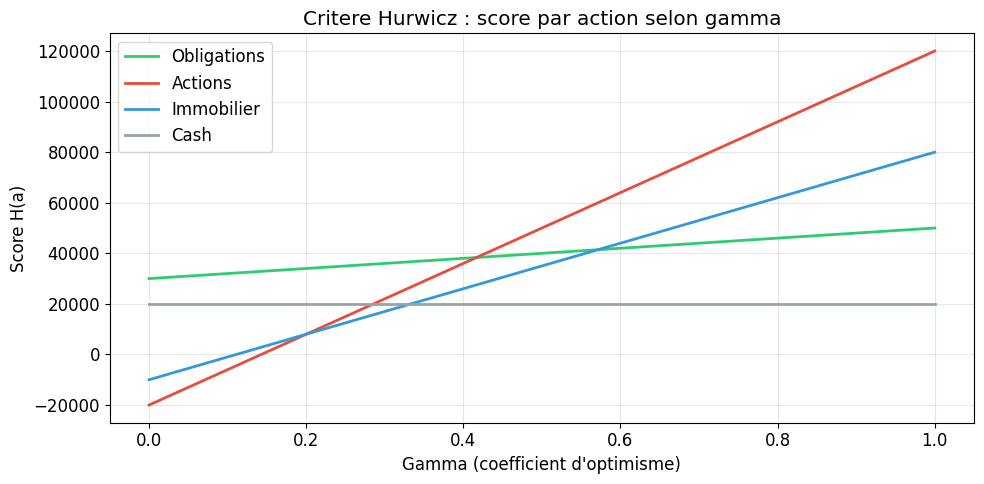

In [7]:
gammas_fine = np.linspace(0, 1, 200)
decisions = []
h_values = {a: [] for a in actions_inv}

for g in gammas_fine:
    best, _ = hurwicz_decision(actions_inv, U_inv, g)
    decisions.append(best)
    h = g * U_inv.max(axis=1) + (1 - g) * U_inv.min(axis=1)
    for i, a in enumerate(actions_inv):
        h_values[a].append(h[i])

fig, ax = plt.subplots(figsize=(10, 5))
colors = {"Obligations": "#2ecc71", "Actions": "#e74c3c",
          "Immobilier": "#3498db", "Cash": "#95a5a6"}
for action in actions_inv:
    ax.plot(gammas_fine, h_values[action], label=action, color=colors[action], linewidth=2)

ax.set_xlabel("Gamma (coefficient d'optimisme)")
ax.set_ylabel("Score H(a)")
ax.set_title("Critere Hurwicz : score par action selon gamma")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## 7. Analyse de sensibilite

Tester la decision sur une plage de P(Recession) revele les **parametres critiques**.

In [8]:
print("=== Analyse de Sensibilite ===\n")
print(f"{'P(Recession)':12s} | {'Meilleure action':16s} | EU")
print("-" * 45)

for p_rec in np.arange(0.10, 0.51, 0.10):
    p_stable = (1 - p_rec) * 0.65
    p_croiss = (1 - p_rec) * 0.35
    p = np.array([p_rec, p_stable, p_croiss])
    
    eu = U_inv @ p  # (4x3) @ (3,) = (4,)
    best_idx = np.argmax(eu)
    print(f"{p_rec:12.0%} | {actions_inv[best_idx]:16s} | {eu[best_idx]:8.0f}")

print("\n=> La decision change entre P(Recession)=30% et 40%.")

=== Analyse de Sensibilite ===

P(Recession) | Meilleure action | EU
---------------------------------------------
         10% | Actions          |    65050
         20% | Actions          |    55600
         30% | Actions          |    46150
         40% | Obligations      |    38100
         50% | Obligations      |    36750

=> La decision change entre P(Recession)=30% et 40%.


## 8. Systeme expert multi-sources

On combine 3 sources d'information avec des fiabilites differentes pour un diagnostic informatique :
- **Logs systeme** : scores par type de panne
- **Avis utilisateur** : peut confondre les symptomes
- **Capteur RAM** : tres fiable pour detecter les pannes RAM

In [9]:
# Systeme expert multi-sources : diagnostic informatique
n_pannes = 4
pannes = ["OK", "RAM", "Disque", "CPU"]
prior_uniform = np.ones(n_pannes) / n_pannes

# Source 1 : Logs systeme (scores de probabilite)
scores_logs = np.array([0.10, 0.15, 0.65, 0.10])  # Suggere Disque

# Source 2 : Matrice de confusion utilisateur
confusion_user = np.array([
    [0.85, 0.05, 0.05, 0.05],  # Vraie panne=OK
    [0.05, 0.60, 0.20, 0.15],  # Vraie panne=RAM
    [0.05, 0.10, 0.75, 0.10],  # Vraie panne=Disque
    [0.05, 0.15, 0.15, 0.65],  # Vraie panne=CPU
])
user_says = 2  # "Disque"

# Source 3 : Capteur RAM (P(alerte|panne))
p_alerte_ram = np.array([0.02, 0.95, 0.05, 0.08])  # Par panne
alerte_ram = False  # Pas d'alerte

# Inference bayesienne : combiner les sources
# Likelihood par source
L1 = scores_logs  # Logs : directement comme likelihood
L2 = confusion_user[:, user_says]  # User : colonne correspondant a l'avis
L3 = np.where(alerte_ram, p_alerte_ram, 1 - p_alerte_ram)  # Capteur

# Posterior : prior * L1 * L2 * L3, normalise
unnormalized = prior_uniform * L1 * L2 * L3
posterior = unnormalized / unnormalized.sum()

print("=== Systeme Expert Bayesien Multi-Sources ===\n")
print("Sources combinees :")
print(f"  1. Logs : {dict(zip(pannes, scores_logs))}")
print(f"  2. Utilisateur dit : {pannes[user_says]}")
print(f"  3. Capteur RAM : {'alerte' if alerte_ram else 'pas d\'alerte'}\n")

print("Posterior sur la panne :")
for i, p in enumerate(pannes):
    bar = '#' * int(posterior[i] * 40)
    print(f"  P({p:6s}) = {posterior[i]:6.1%} {bar}")

# Decision : matrice de couts
couts = np.array([
    #  OK    RAM   Disk   CPU
    [   0, -500, -1000, -800],  # Rien
    [-100,    0,  -900, -700],  # Remplacer RAM
    [-150, -400,     0, -600],  # Remplacer Disque
    [-300, -300,  -800,    0],  # Remplacer CPU
])
actions_rep = ["Rien", "Remplacer RAM", "Remplacer Disque", "Remplacer CPU"]

print("\nUtilites esperees :")
eu_rep = couts @ posterior  # U transpose * posterior
for a in range(len(actions_rep)):
    print(f"  E[U({actions_rep[a]:18s})] = {eu_rep[a]:7.0f}")

best = np.argmax(eu_rep)
print(f"\n=> Recommandation : {actions_rep[best]} (EU = {eu_rep[best]:.0f})")

=== Systeme Expert Bayesien Multi-Sources ===

Sources combinees :
  1. Logs : {'OK': np.float64(0.1), 'RAM': np.float64(0.15), 'Disque': np.float64(0.65), 'CPU': np.float64(0.1)}
  2. Utilisateur dit : Disque
  3. Capteur RAM : pas d'alerte

Posterior sur la panne :
  P(OK    ) =   1.0% 
  P(RAM   ) =   0.3% 
  P(Disque) =  95.8% ######################################
  P(CPU   ) =   2.9% #

Utilites esperees :
  E[U(Rien              )] =    -983
  E[U(Remplacer RAM     )] =    -883
  E[U(Remplacer Disque  )] =     -20
  E[U(Remplacer CPU     )] =    -771

=> Recommandation : Remplacer Disque (EU = -20)


### Interpretation du diagnostic multi-sources

Les 3 sources convergent vers **Disque** :
- Logs suggerent Disque (score 0.65)
- Utilisateur dit Disque (75% correct si c'est vraiment Disque)
- Capteur RAM negatif exclut fortement RAM (P(RAM) tombe a ~1%)

La decision "Remplacer Disque" est robuste car P(Disque) est eleve et le cout
de ne rien faire si c'est Disque est catastrophique (-1000).

## 9. Decision medicale robuste

On applique les 3 criteres a un scenario medical avec 3 etats et 3 traitements.

In [10]:
# Scenario medical robuste
etats_med = ["Benin", "Modere", "Grave"]
traitements = ["Aucun", "Leger", "Intensif"]
U_med = np.array([
    [100, 60, 10],   # Aucun
    [ 90, 80, 40],   # Leger
    [ 70, 85, 80],   # Intensif
])

def analyze_medical(posteriors_med, scenario_name):
    print(f"\n{'='*10} {scenario_name} {'='*10}")
    print(f"Posterieurs : {', '.join(f'{e}={p:.0%}' for e, p in zip(etats_med, posteriors_med))}\n")
    
    # Max EU
    eu = U_med @ posteriors_med  # (3x3) @ (3,) = (3,)
    best_eu = np.argmax(eu)
    print("Max EU :")
    for a, t in enumerate(traitements):
        print(f"  E[U({t})] = {eu[a]:.1f}")
    print(f"  => {traitements[best_eu]}\n")
    
    # Minimax
    best_mm, val_mm = minimax_decision(traitements, etats_med, U_med)
    print(f"Minimax : {best_mm} (pire cas = {val_mm:.0f})")
    
    # Minimax Regret
    best_mr, val_mr, _ = minimax_regret_decision(traitements, etats_med, U_med)
    print(f"Minimax Regret : {best_mr} (max regret = {val_mr:.0f})")
    
    # Recommandation
    if posteriors_med[2] > 0.30:
        print(f"\nATTENTION : P(Grave) = {posteriors_med[2]:.0%} > 30%")
        print(f"Recommandation conservative : {best_mm}")
    else:
        print(f"\nRecommandation (EU) : {traitements[best_eu]}")

analyze_medical(np.array([0.70, 0.25, 0.05]), "Faible risque")
analyze_medical(np.array([0.20, 0.40, 0.40]), "Risque eleve")


========== Faible risque ==========
Posterieurs : Benin=70%, Modere=25%, Grave=5%

Max EU :
  E[U(Aucun)] = 85.5
  E[U(Leger)] = 85.0
  E[U(Intensif)] = 74.2
  => Aucun

Minimax : Intensif (pire cas = 70)
Minimax Regret : Intensif (max regret = 30)

Recommandation (EU) : Aucun

========== Risque eleve ==========
Posterieurs : Benin=20%, Modere=40%, Grave=40%

Max EU :
  E[U(Aucun)] = 48.0
  E[U(Leger)] = 66.0
  E[U(Intensif)] = 80.0
  => Intensif

Minimax : Intensif (pire cas = 70)
Minimax Regret : Intensif (max regret = 30)

ATTENTION : P(Grave) = 40% > 30%
Recommandation conservative : Intensif


### Lecon medicale

- **Faible risque** : Max EU recommande "Aucun", mais Minimax dit "Intensif".
  On fait confiance aux probabilites car P(Grave) < 30%.
- **Risque eleve** : Les 3 criteres convergent vers "Intensif".
  La convergence renforce la confiance dans la recommandation.

## 10. Exercice : Systeme expert informatique

Construisez un mini-systeme expert pour diagnostiquer des problemes informatiques.

**Symptomes** : lenteur, ecran_bleu, bruit_ventilateur, surchauffe
**Causes** : virus, disque_plein, RAM_defaillante, surchauffe_CPU

In [11]:
# Exercice : systeme expert informatique
causes = ["virus", "disque_plein", "RAM_defaillante", "surchauffe_CPU"]
symptomes_it = ["lenteur", "ecran_bleu", "bruit_ventilateur", "surchauffe"]
actions_it = ["antivirus", "nettoyage_disque", "remplacement_RAM", "nettoyage_ventilateur"]
symptomes_obs_it = ["lenteur", "bruit_ventilateur"]

print(f"Symptomes observes : {', '.join(symptomes_obs_it)}")

# TODO 1 : Definir les priors (somme = 1)
# TODO 2 : Definir les likelihoods P(symptome | cause)
# TODO 3 : Definir la matrice d'utilite U(action, cause)
# TODO 4 : Calculer les posteriors P(cause | symptomes)
# TODO 5 : Calculer minimax regret et max EU
print("Exercice a completer")

Symptomes observes : lenteur, bruit_ventilateur
Exercice a completer


## 11. Tableau recapitulatif

| Concept | Formule | Usage |
|---------|---------|-------|
| Minimax | $\max_a \min_s U(a,s)$ | Decision conservative |
| Minimax Regret | $\min_a \max_s \text{Regret}(a,s)$ | Compromis |
| Hurwicz | $\gamma \max + (1-\gamma) \min$ | Parametre d'optimisme |
| Sensibilite | Varier P(etat) | Parametres critiques |
| Multi-sources | Bayes + fiabilite | Fusion d'informations |

## Points cles

1. **Minimax** garantit un plancher mais est souvent trop pessimiste
2. **Minimax Regret** minimise les opportunites manquees
3. **Hurwicz** offre un compromis continu entre pessimisme et optimisme
4. **L'analyse de sensibilite** revele les parametres critiques
5. **La convergence des criteres** renforce la confiance dans la decision
6. **La divergence** signale une situation d'incertitude reelle

---

**References** :
- Wald (1950), *Statistical Decision Functions*
- Savage (1951), *The Theory of Statistical Decision*
- Pearl (1988), *Probabilistic Reasoning in Intelligent Systems*